# Imports
Functions are kept in a seperate file to not clutter this report uneccessarily. Most imports are in functions.py

In [18]:
from functions import *

# Read and view data
Setting path variables to the training and test data.

Makes a dataset for training, validation and testing.

Show general information about the data. Shape and the different classes. Also confirms that 20% of the total data is for testing. The remaining 80% of the data consists of training and validation data.

In [ ]:
train_path = "Data/train/"
test_path = "Data/test/"

# Create a training set
print("Train dataset:")
train_ds, class_names = load_images_from_dir(train_path, (48, 48), "training")

# Create a validation set
print("\nValidation dataset:")
val_ds, _ = load_images_from_dir(train_path, (48, 48), "validation")

# Create a test set
print("\nTest dataset:")
test_ds, _ = load_images_from_dir(test_path, (48, 48), "")

# Check classes
print(f"\nClasses: {class_names}")

# View class names for training set
train_df = return_class_count_df(train_path)
print(f"\nTraining/Validation class distribution: \n{train_df}")

# View class names for test set
test_df = return_class_count_df(test_path)
print(f"\nTest class distribution: \n{test_df}")

# Check if the train and test data are split 80/20
print(f"\nPercentage of data in train/val dataset: {count_files(train_path) / (count_files(train_path) + count_files(test_path)):0.2f}")
print(f"Percentage of data in test dataset: {count_files(test_path) / (count_files(train_path) + count_files(test_path)):0.2f}")

Train dataset:
Found 28709 files belonging to 7 classes.
Using 22968 files for training.

Validation dataset:


E0000 00:00:1779783686.759740   22046 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 28709 files belonging to 7 classes.
Using 5741 files for validation.

Test dataset:
Found 7178 files belonging to 7 classes.

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Training/Validation classes: 
      Class  Images
0   disgust     436
1   neutral    4965
2  surprise    3171
3     happy    7215
4      fear    4097
5       sad    4830
6     angry    3995

Test classes: 
      Class  Images
0   disgust     111
1   neutral    1233
2  surprise     831
3     happy    1774
4      fear    1024
5       sad    1247
6     angry     958

Percentage of data in train/val dataset: 0.80
Percentage of data in test dataset: 0.20


Plotting n number of images to get an idea of what the data consists of.

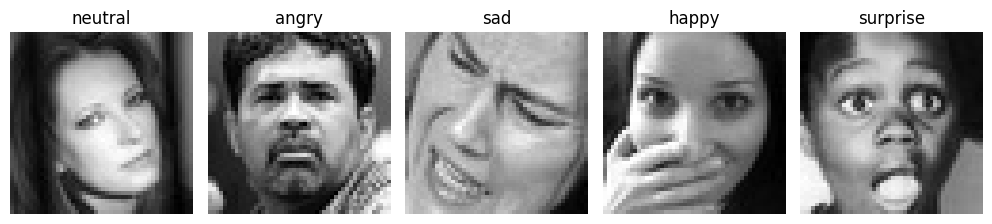

In [3]:
plot_n_images(train_ds, class_names, 5)

# Models
There will be 7 different models tested in 3 phases and the best one chosen for test data.

Phase 1 and 2 will have fixed epochs at 20 for a fair comparison. Phase 3 will have early stop to reduce training time and final tuning.

The following models will be:

**Phase 1**

1. baseline

**Phase 2**

2. baseline + dropout
3. baseline + GAP
4. baseline + mild augmentation

**Phase 3**

5. best of phase 2 + x
6. best of phase 2 + x
7. best of phase 2 + x

where x is determined later based on the results of models 1, 2, 3 and 4.

In [4]:
models = []     # Each new model object is added here
histories = []  # Each model's history object is added here
results = []    # List of dictionary containing model name, final train/val acc, best val acc/loss and best epoch

All models in phase 1 and 2 will have a fixed epoch at 20 to clearly see the graphs and make a decision as to which model to bring to phase 3.

All models in phase 3 will include an early stop to save on training time and pick the best model based on an early stop.

# Phase 1

## Model 1 - Baseline
This model acts as the baseline to compare different models to.

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3182 - loss: 1.6894 - val_accuracy: 0.4173 - val_loss: 1.5279
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4537 - loss: 1.4315 - val_accuracy: 0.4740 - val_loss: 1.3742
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5109 - loss: 1.2855 - val_accuracy: 0.5072 - val_loss: 1.2871
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5552 - loss: 1.1852 - val_accuracy: 0.5285 - val_loss: 1.2564
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5886 - loss: 1.0950 - val_accuracy: 0.5353 - val_loss: 1.2301
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6189 - loss: 1.0143 - val_accuracy: 0.5292 - val_loss: 1.2657
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6532 - loss: 0.9306 - val_accuracy: 0.5370 - val_loss: 1.2855
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6897 - loss: 0.8428 - val_accuracy: 0.

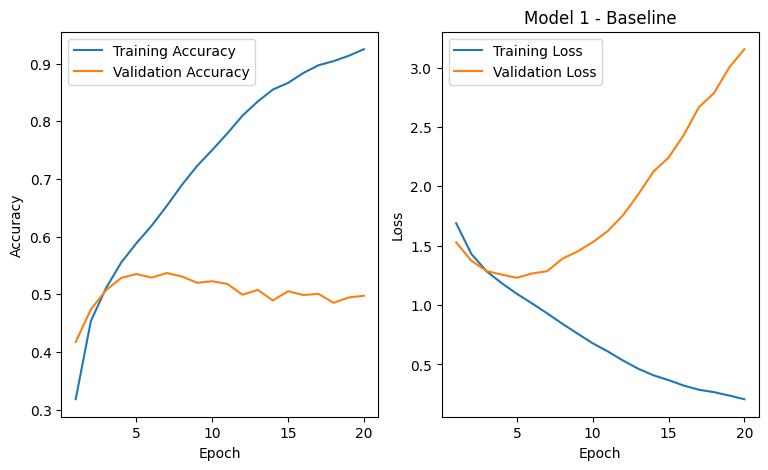

In [5]:
baseline_layers = [
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(7, activation="softmax")
]

model_baseline = create_model(baseline_layers)
history_baseline = train_model(model_baseline, train_ds, val_ds, 20, None)
save_model_info(models, histories, results, model_baseline, history_baseline, "baseline")
plot_history_data(history_baseline.history, "Model 1 - Baseline")

The baseline model shows overfitting because training accuracy continues increasing while validation performance stops improving and later declines. This is likely due to the lack of regularization and the use of Flatten(), which increases the number of parameters and allows the model to memorize training-specific patterns rather than generalize well.

# Phase 2

## Model 2 - Dropout 0.3

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3222 - loss: 1.6929 - val_accuracy: 0.4302 - val_loss: 1.4988
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4371 - loss: 1.4593 - val_accuracy: 0.4797 - val_loss: 1.3565
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4839 - loss: 1.3481 - val_accuracy: 0.5039 - val_loss: 1.2885
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5137 - loss: 1.2677 - val_accuracy: 0.5168 - val_loss: 1.2551
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5404 - loss: 1.2022 - val_accuracy: 0.5220 - val_loss: 1.2440
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5686 - loss: 1.1302 - val_accuracy: 0.5266 - val_loss: 1.2393
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5948 - loss: 1.0655 - val_accuracy: 0.5334 - val_loss: 1.2431
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6166 - loss: 1.0111 - val_accuracy: 0.

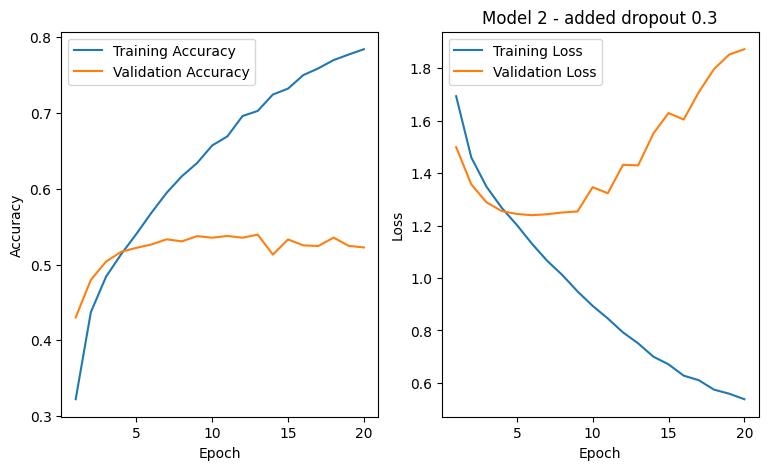

In [6]:
dropout_03_layers = [
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(7, activation="softmax")
]

model_dropout_03 = create_model(dropout_03_layers)
history_dropout_03 = train_model(model_dropout_03, train_ds, val_ds, 20, None)
save_model_info(models, histories, results, model_dropout_03, history_dropout_03, "dropout 0.3")
plot_history_data(history_dropout_03.history, "Model 2 - added dropout 0.3")

Adding a Dropout(0.3) layer reduced overfitting and improved validation performance, but the model still shows some divergence later in training. Dropout works by randomly disabling neurons during training, reducing dependence on specific patterns and improving generalization. However, the model still retains enough capacity to memorize parts of the training data.

## Model 3 - Global Average Pooling

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2524 - loss: 1.8040 - val_accuracy: 0.2472 - val_loss: 1.7785
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2654 - loss: 1.7773 - val_accuracy: 0.2635 - val_loss: 1.7707
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.2963 - loss: 1.7289 - val_accuracy: 0.3315 - val_loss: 1.6781
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3509 - loss: 1.6306 - val_accuracy: 0.3559 - val_loss: 1.5929
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3941 - loss: 1.5456 - val_accuracy: 0.3989 - val_loss: 1.5481
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4286 - loss: 1.4824 - val_accuracy: 0.4304 - val_loss: 1.4816
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4508 - loss: 1.4286 - val_accuracy: 0.4534 - val_loss: 1.4221
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4665 - loss: 1.3878 - val_accuracy: 0.

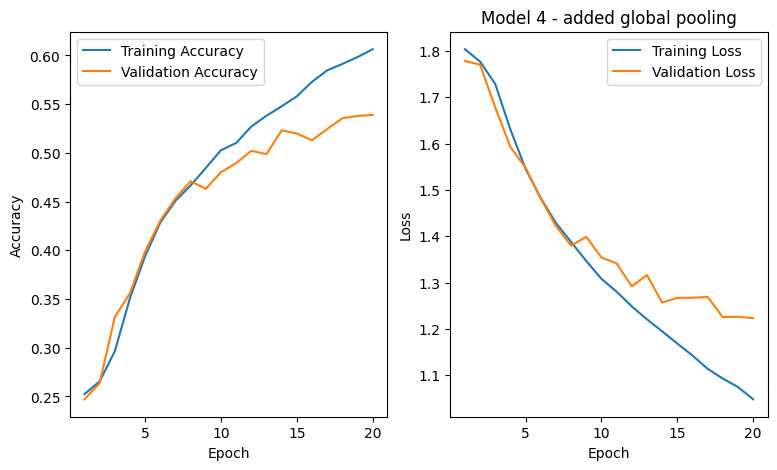

In [7]:
global_pooling_layers = [
    layers.Input(shape=(48, 48, 1)),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(7, activation="softmax")
]

model_global_pooling = create_model(global_pooling_layers)
history_global_pooling = train_model(model_global_pooling, train_ds, val_ds, 20, None)
save_model_info(models, histories, results, model_global_pooling, history_global_pooling, "global pooling")
plot_history_data(history_global_pooling.history, "Model 4 - added global pooling")

The GlobalAveragePooling2D() layer reduced overfitting significantly and produced a much more stable model than the baseline. Some mild divergence still appears in later epochs as training performance continues improving while validation performance begins to plateau. GlobalAveragePooling2D() reduces overfitting by summarizing each feature map into a single value instead of preserving all spatial activations like Flatten(). This encourages the model to focus on overall feature strength rather than exact locations, helping it learn more general patterns instead of memorizing specific ones.

## Model 4 - Mild Augmentation

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2740 - loss: 1.7636 - val_accuracy: 0.3212 - val_loss: 1.6699
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3590 - loss: 1.6271 - val_accuracy: 0.4052 - val_loss: 1.5269
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4245 - loss: 1.4951 - val_accuracy: 0.4597 - val_loss: 1.4044
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4587 - loss: 1.4129 - val_accuracy: 0.4794 - val_loss: 1.3624
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4781 - loss: 1.3633 - val_accuracy: 0.5037 - val_loss: 1.3008
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4974 - loss: 1.3235 - val_accuracy: 0.5156 - val_loss: 1.2765
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5084 - loss: 1.2922 - val_accuracy: 0.5212 - val_loss: 1.2548
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5216 - loss: 1.2622 - val_accuracy: 0.

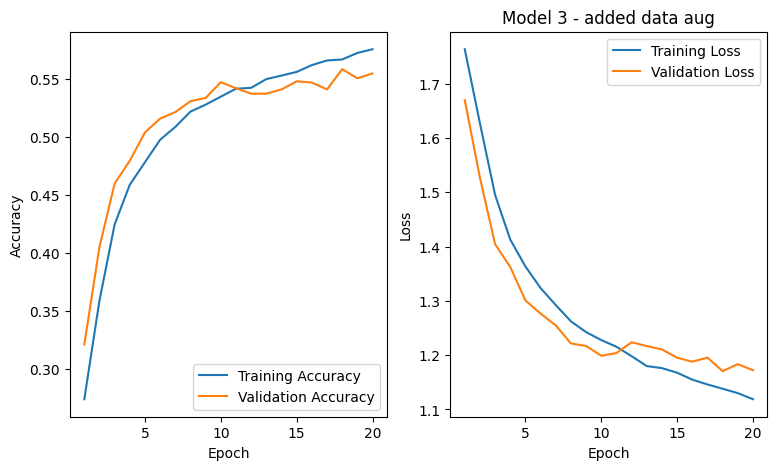

In [8]:
data_aug_layers = [
    layers.Input(shape=(48, 48, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),

    layers.Dense(7, activation="softmax")
]

model_data_aug = create_model(data_aug_layers)
history_data_aug = train_model(model_data_aug, train_ds, val_ds, 20, None)
save_model_info(models, histories, results, model_data_aug, history_data_aug, "data augmentation")
plot_history_data(history_data_aug.history, "Model 3 - added data aug")

Mild data augmentation reduced overfitting significantly and no clear divergence is visible after 20 epochs. Around epochs 10–11, validation performance briefly becomes better than training performance. This is common with data augmentation because the training images are intentionally made more difficult. Data augmentation performs well for image tasks because it creates more varied examples, encouraging the model to learn robust features rather than memorizing exact pixel locations of facial characteristics such as the mouth, nose, or eyes.

# Phase 3

Based on previous results the data augmentation gave the best improvement. This model will be tested with the following configurations including early stop:

**Phase 3**

5. model 4 + dropout 0.3
6. model 4 + GAP
7. model 4 + dropout 0.3 + GAP

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    min_delta=0.001,
    restore_best_weights=True
)

## Model 5 - Model4 + Mild Augmentation + Dropout

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.2594 - loss: 1.7918 - val_accuracy: 0.3209 - val_loss: 1.6913
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3138 - loss: 1.7032 - val_accuracy: 0.3682 - val_loss: 1.6079
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3605 - loss: 1.6241 - val_accuracy: 0.4156 - val_loss: 1.5076
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3905 - loss: 1.5667 - val_accuracy: 0.4295 - val_loss: 1.4571
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4121 - loss: 1.5145 - val_accuracy: 0.4565 - val_loss: 1.4052
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4325 - loss: 1.4698 - val_accuracy: 0.4773 - val_loss: 1.3735
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4441 - loss: 1.4450 - val_accuracy: 0.4776 - val_loss: 1.3644
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4547 - loss: 1.4224 - val_accuracy: 0.

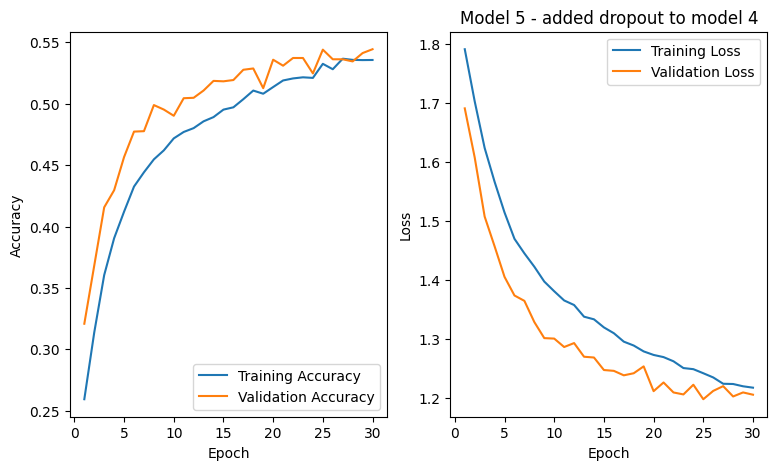

In [10]:
model4_dropout_layers = [
    layers.Input(shape=(48, 48, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(7, activation="softmax")
]

model_model4_dropout = create_model(model4_dropout_layers)
history_model4_dropout = train_model(model_model4_dropout, train_ds, val_ds, 30, early_stop)
save_model_info(models, histories, results, model_model4_dropout, history_model4_dropout, "model 4 + dropout")
plot_history_data(history_model4_dropout.history, "Model 5 - added dropout to model 4")

Adding Dropout(0.3) to Model 4 appears to make the training and validation curves converge around epoch 30, suggesting improved generalization. However, it is difficult to conclude that true convergence has occurred from a limited number of epochs. Training for longer could still cause the curves to separate again, similar to the behavior observed in the data augmentation model.

## Model 6 - Model4 + Mild Augmentation + GAP

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2538 - loss: 1.8009 - val_accuracy: 0.2486 - val_loss: 1.7818
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2583 - loss: 1.7823 - val_accuracy: 0.2562 - val_loss: 1.7677
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2693 - loss: 1.7690 - val_accuracy: 0.2757 - val_loss: 1.7485
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2846 - loss: 1.7441 - val_accuracy: 0.2912 - val_loss: 1.7153
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3152 - loss: 1.6947 - val_accuracy: 0.3470 - val_loss: 1.6167
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3501 - loss: 1.6288 - val_accuracy: 0.3747 - val_loss: 1.5631
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3791 - loss: 1.5711 - val_accuracy: 0.4024 - val_loss: 1.5273
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4014 - loss: 1.5367 - val_accuracy: 0.

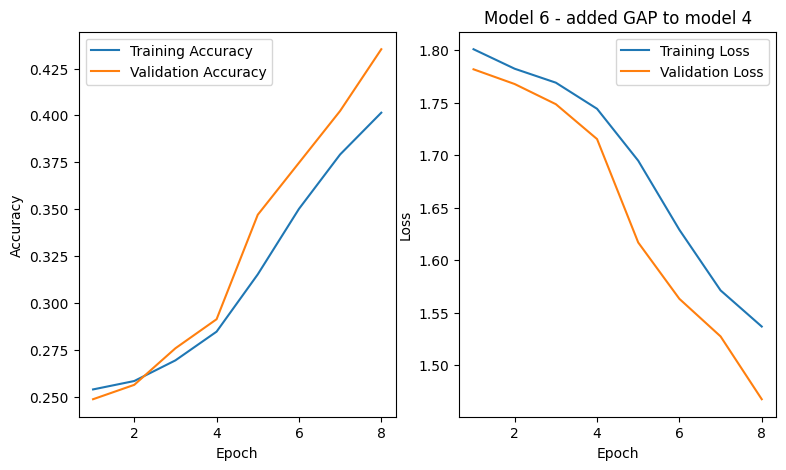

In [11]:
model4_gap_layers = [
    layers.Input(shape=(48, 48, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),

    layers.Dense(7, activation="softmax")
]

model_model4_gap = create_model(model4_gap_layers)
history_model4_gap = train_model(model_model4_gap, train_ds, val_ds, 30, early_stop)
save_model_info(models, histories, results, model_model4_gap, history_model4_gap, "model 4 + GAP")
plot_history_data(history_model4_gap.history, "Model 6 - added GAP to model 4")

Training and validation curves improve together with only a small gap between them, indicating reduced overfitting. However, both accuracies remain relatively low, suggesting added underfitting. The use of GlobalAveragePooling2D appears to reduce model capacity too much, limiting the model's ability to learn more complex facial patterns.

## Model 7 - Model4 + Mild Augmentation + dropout + GAP

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2493 - loss: 1.8159 - val_accuracy: 0.2489 - val_loss: 1.7857
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2551 - loss: 1.7951 - val_accuracy: 0.2494 - val_loss: 1.7784
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2577 - loss: 1.7865 - val_accuracy: 0.2588 - val_loss: 1.7697
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2665 - loss: 1.7753 - val_accuracy: 0.2836 - val_loss: 1.7504
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2794 - loss: 1.7557 - val_accuracy: 0.3116 - val_loss: 1.6945
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3032 - loss: 1.7095 - val_accuracy: 0.3269 - val_loss: 1.6570
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3248 - loss: 1.6712 - val_accuracy: 0.3527 - val_loss: 1.6006
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3476 - loss: 1.6251 - val_accuracy: 0.

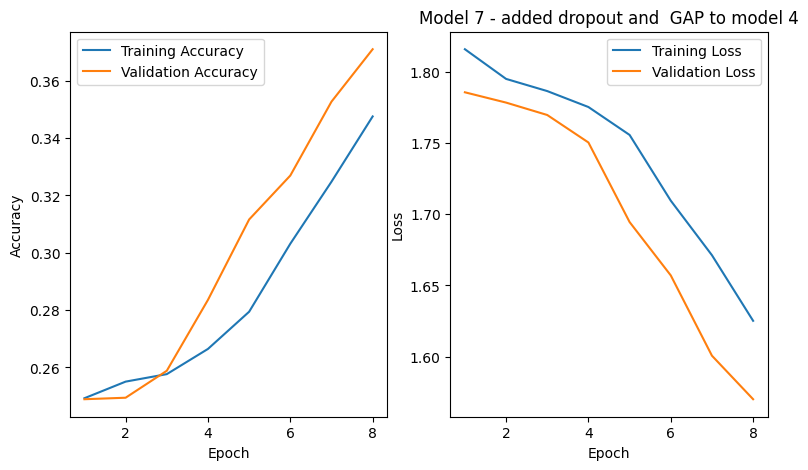

In [12]:
model4_dropout_gap_layers = [
    layers.Input(shape=(48, 48, 1)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(7, activation="softmax")
]

model_model4_dropout_gap = create_model(model4_dropout_gap_layers)
history_model4_dropout_gap = train_model(model_model4_dropout_gap, train_ds, val_ds, 30, early_stop)
save_model_info(models, histories, results, model_model4_dropout_gap, history_model4_dropout_gap, "model 4 + dropout + GAP")
plot_history_data(history_model4_dropout_gap.history, "Model 7 - added dropout and  GAP to model 4")

Training and validation curves improve together with only a small gap between them, indicating reduced overfitting. However, the lower overall accuracy compared to previous models suggests some underfitting. The combination of GlobalAveragePooling2D() and Dropout appears to reduce model capacity too much, limiting the model's ability to learn important features from the images.

# Results

In [13]:
results_df = pd.DataFrame(results)
display(results_df)

,model name,train acc at best epoch,best val acc,best val loss,gap,best epoch
0,baseline,0.653213,0.537014,1.230101,0.116199,6
1,dropout 0.3,0.702804,0.539453,1.239262,0.163351,12
2,global pooling,0.606409,0.538930,1.223027,0.067478,19
3,data augmentation,0.566484,0.558091,1.170466,0.008393,17
4,model 4 + dropout,0.535571,0.544330,1.197338,-0.008759,29
5,model 4 + GAP,0.401428,0.435290,1.467413,-0.033862,7
6,model 4 + dropout + GAP,0.347571,0.371015,1.570030,-0.023445,7


## Chose the best model

The best model will be determined by the best validation accuracy and loss, along with the gap

The best validation accuracy says how well the model performs on unseen data, the best validation loss how confident the model is and finally the gap, telling if the model generalizes or memorizes.

In [14]:
results_df = results_df.sort_values(
    by=["best val acc", "best val loss", "gap"],
    ascending=[False, True, True]
)
display(results_df)
best_model = results_df.iloc[0]
print(f"Best model: {best_model}")

,model name,train acc at best epoch,best val acc,best val loss,gap,best epoch
3,data augmentation,0.566484,0.558091,1.170466,0.008393,17
4,model 4 + dropout,0.535571,0.544330,1.197338,-0.008759,29
1,dropout 0.3,0.702804,0.539453,1.239262,0.163351,12
2,global pooling,0.606409,0.538930,1.223027,0.067478,19
0,baseline,0.653213,0.537014,1.230101,0.116199,6
5,model 4 + GAP,0.401428,0.435290,1.467413,-0.033862,7
6,model 4 + dropout + GAP,0.347571,0.371015,1.570030,-0.023445,7


Best model: model name                 data augmentation
train acc at best epoch             0.566484
best val acc                        0.558091
best val loss                       1.170466
gap                                 0.008393
best epoch                                17
Name: 3, dtype: object


According to these results, the baseline model with data augmentation is the best model. It shows minimal signs of overfitting compared to previous models and the gap between training and validation is the smallest. It does not memorize as much but rather generalizes which is what is desired.

# Evaluation on test data using the best model

In [15]:
test_loss, test_acc = model_data_aug.evaluate(test_ds)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5553 - loss: 1.1776
Test accuracy: 0.5553
Test loss: 1.1776


The baseline model has a very high training accuracy but had massive overfitting, indicated by a large gap between training and validation performance. The baseline model using data augmentation provided the best balance between learning and generalization, resulting in the highest validation accuracy and lowest validation loss. Evaluation on the test dataset produced similar results to the validation phase (55.5% test accuracy), suggesting that the model generalized well to previously unseen data rather than memorizing.

# Testing model on n random faces
This section tests the model on randomly pulled faced from the test data to see how well the model performs.

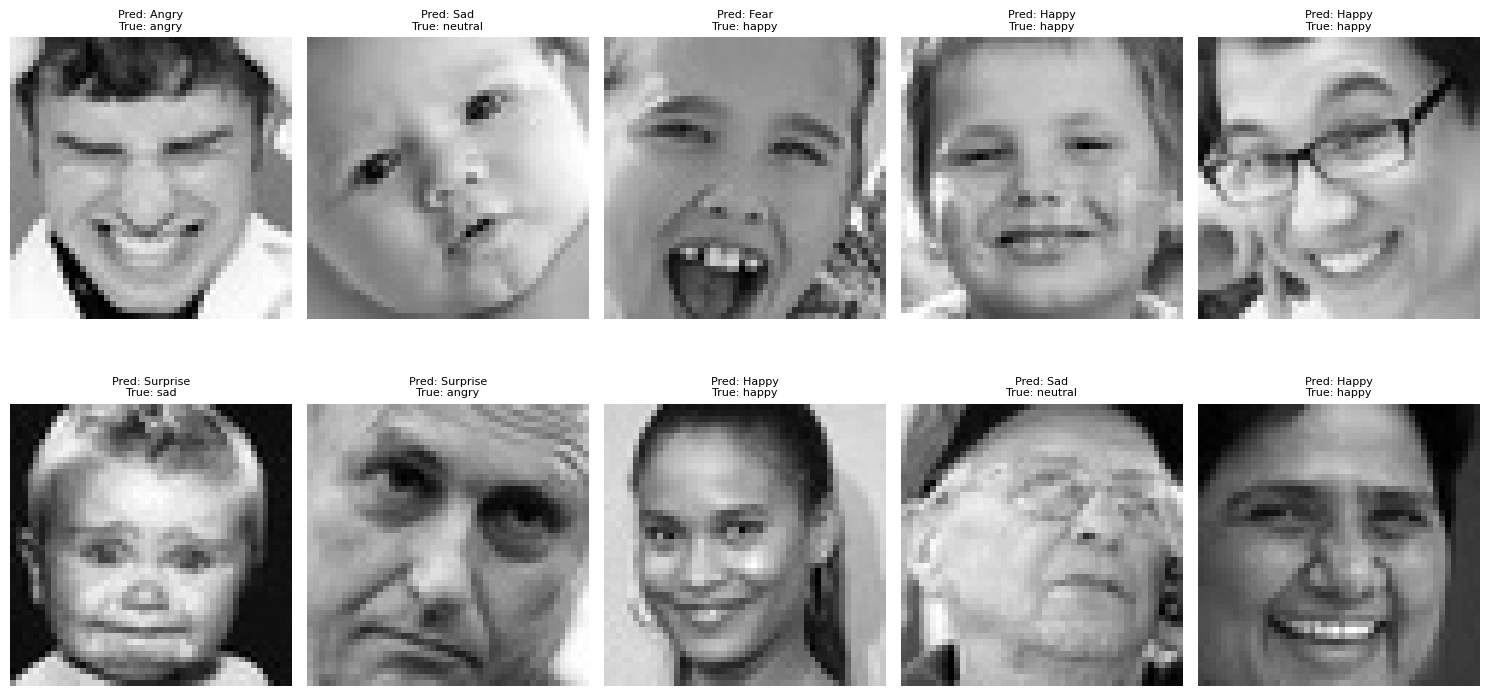

Correct answers: 50.0%


In [24]:
import random

# Get all image files from all class subfolders
image_files = []

for class_folder in Path(test_path).iterdir():
    if class_folder.is_dir():
        image_files.extend(class_folder.glob("*"))

# Grab 10 random images
random_images = random.sample(image_files, 10)

class_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

correct_guesses = 0

plt.figure(figsize=(15,8))
for i, img_path in enumerate(random_images):

    # Load image
    img = tf.keras.utils.load_img(
        img_path,
        color_mode="grayscale",
        target_size=(48,48)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0 # Normalize

    # Add batch dimension
    img_input = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model_data_aug.predict(img_input, verbose=0)

    # Predicted class
    predicted_class = class_names[np.argmax(pred)]

    # Correct class
    true_class = img_path.parent.name

    # Check if the predicted class is equal to the correct class
    if (str.lower(predicted_class) == str.lower(true_class)):
        correct_guesses += 1

    # Show image
    plt.subplot(2,5,i+1)
    plt.imshow(img_array.squeeze(), cmap="gray")
    plt.axis("off")

    plt.title(
        f"Pred: {predicted_class}\nTrue: {true_class}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print(f"Correct answers: {(correct_guesses / 10) * 100}%")

# Saving model and loading model to test on 5 random faces not from the dataset

In [ ]:
model_data_aug.save("model_data_aug.keras")

In [27]:
loaded_model = tf.keras.models.load_model("model_data_aug.keras")

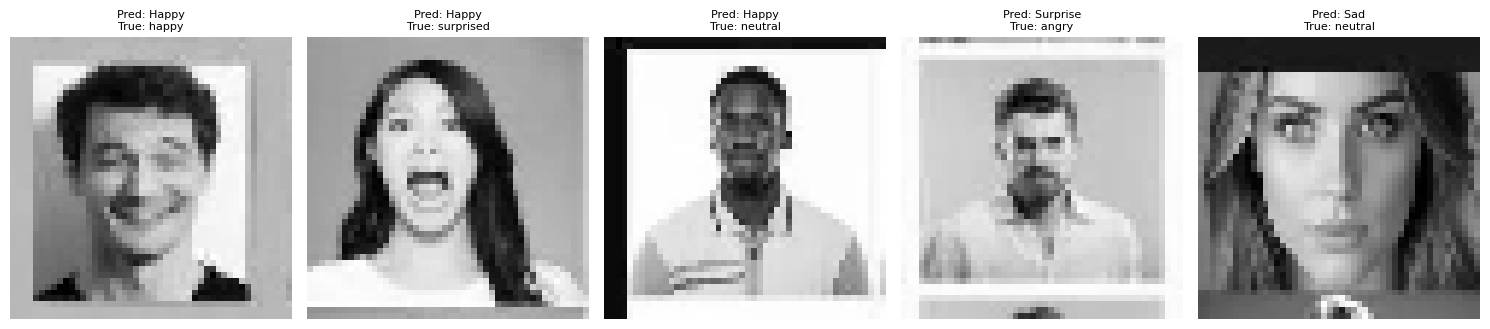

Correct answers: 10.0%


In [59]:
# Get all image files from all class subfolders
image_files_2 = []

new_img_path = "Data/new/"

for class_folder in Path(new_img_path).iterdir():
    if class_folder.is_dir():
        image_files_2.extend(class_folder.glob("*"))

# Grab 10 random images
random_images = random.sample(image_files_2, 5)

class_names = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
]

correct_guesses = 0

plt.figure(figsize=(15,8))
for i, img_path in enumerate(random_images):

    # Load image
    img = tf.keras.utils.load_img(
        img_path,
        color_mode="grayscale",
        target_size=(48,48)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0 # Normalize

    # Add batch dimension
    img_input = np.expand_dims(img_array, axis=0)

    # Predict
    pred = model_data_aug.predict(img_input, verbose=0)

    # Predicted class
    predicted_class = class_names[np.argmax(pred)]

    # Correct class
    true_class = img_path.parent.name

    # Check if the predicted class is equal to the correct class
    if (str.lower(predicted_class) == str.lower(true_class)):
        correct_guesses += 1

    # Show image
    plt.subplot(2,5,i+1)
    plt.imshow(img_array.squeeze(), cmap="gray")
    plt.axis("off")

    plt.title(
        f"Pred: {predicted_class}\nTrue: {true_class}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print(f"Correct answers: {(correct_guesses / 10) * 100}%")

The model was also tested on five completely unseen facial images. The results were weaker than expected compared to the model’s validation performance. This is likely due to a domain shift between the training data and these images. The training data consists of tightly cropped, low-resolution grayscale facial images, while the new images contain additional background information, uneven cropping, and varying resolution. In some cases, large black or grey borders and heavy pixelation reduce the visibility of facial features, making it harder for the model to extract meaningful patterns. This leads to confusion between similar expressions, such as surprised and happy or neutral and slightly expressive faces.

# Conclusion

The experiments show that data augmentation provides the strongest improvement in performance. By increasing the diversity of the training data through random flips and rotations, the model is encouraged to learn more robust and general features rather than memorizing training examples. This results in higher validation accuracy and a significantly smaller train–validation gap compared to other models.

Global Average Pooling reduced model performance when combined with other regularization techniques because it strongly decreases the number of learnable parameters. While this can help reduce overfitting, in this experiment it reduced the model’s capacity too much, leading to underfitting, which is visible in lower training and validation accuracy.

Models combining multiple regularization methods performed worse than individual modifications because the overall capacity of the network became too limited. Since data augmentation already improved generalization, adding both dropout and GAP further restricted learning, resulting in underfitting.

Overall, the results highlight that improving performance is not about adding more regularization techniques, but about balancing model capacity and data complexity.

# Reflection

The most challenging part of the assignment was deciding which architectural changes to test, since there are many possible modifications such as additional layers, regularization techniques, and data augmentation strategies. The main difficulty was avoiding changing too many variables at once, which would have made comparisons unclear.

I learned the importance of structured experimentation, where only one or a few variables are changed at a time. This made it easier to understand how each modification affected model performance and generalization.

If I were to redo the assignment, I would reduce dataset size or use faster training strategies earlier in development to speed up experimentation. This would allow more systematic testing without long waiting times.

I believe the work corresponds to VG because multiple model architectures were compared systematically, model performance was improved through experimentation with regularization methods, and the training curves were analyzed to explain differences in overfitting and underfitting behavior. The discussion also includes limitations and generalization considerations rather than only reporting accuracy values.